## Library

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path
from scipy import stats
import statsmodels.api as sm
from dotenv import load_dotenv
from google.cloud import bigquery
warnings.filterwarnings("ignore")

In [2]:
load_dotenv()

PROJECT_ROOT = Path.cwd().parents[0]  # jupyter/ -> bgg/
DATA_DIR = PROJECT_ROOT / "data" / "after"
CACHE_DIR = DATA_DIR / "nb_cache_02"  # 01(nb_cache)과 분리 — 02 전용 캐시
CACHE_DIR.mkdir(parents=True, exist_ok=True)
PROJECT_ID = os.environ["GCP_PROJECT_ID"]
client = bigquery.Client(project=PROJECT_ID)

print(f"ROOT:\t{PROJECT_ROOT}")
print(f"CACHE:\t{CACHE_DIR}")
print(f"GCP:\tConnected to Project: {client.project}")

ROOT:	/Users/mungughyeon/Documents/internship/Likelion/bgg
CACHE:	/Users/mungughyeon/Documents/internship/Likelion/bgg/data/after/nb_cache_02
GCP:	Connected to Project: bgg-user-analytics


In [3]:
import sys
sys.path.insert(0, str(PROJECT_ROOT))
from src.utils import setup_font
from src.preprocess.eda import AdvanceEDA


def load_cache(name: str, sql: str, refresh: bool = False) -> pd.DataFrame:
    """캐시 CSV가 있으면 그걸 읽고, 없거나 refresh=True면 BigQuery에 쿼리해 캐시"""
    cache_path = CACHE_DIR / f"{name}.csv"
    if not cache_path.exists() or refresh:
        client.query(sql).to_dataframe().to_csv(cache_path, index=False)
    return pd.read_csv(cache_path)

Hangul OK in your MAC!


- **이 노트북은 `stg_user_item`을 다시 정제하지 않는다.** 
- `bgg_mart.funnel_user`/`funnel_item`은 01에서 확정한 중복 제거·`user_rating` 백필 규칙이 이미 반영된 마트다(`sql/marts/funnel.sql`). 
- 02는 이 마트를 신뢰 소스로 그대로 쓰고, 유저 정보(`stg_user_info`)와 게임 인기도(`stg_item_stats.owned`)만 추가로 조인한다.

In [4]:
funnel_user = load_cache("funnel_user", '''
    SELECT * FROM `bgg_mart.funnel_user`
''')

funnel_user_summary = load_cache("funnel_user_summary", '''
    SELECT * FROM `bgg_mart.funnel_user_summary` ORDER BY stage_order
''')

funnel_core_segment = load_cache("funnel_core_segment", '''
    SELECT * FROM `bgg_mart.funnel_user_core_segment`
''')

funnel_item = load_cache("funnel_item", '''
    SELECT * FROM `bgg_mart.funnel_item`
''')

funnel_item_by_complexity = load_cache("funnel_item_by_complexity", '''
    SELECT * FROM `bgg_mart.funnel_item_by_complexity` ORDER BY complexity_bucket
''')

user_info = load_cache("user_info_02", '''
    SELECT user_id, yearregistered, lastlogin FROM `bgg_staging.stg_user_info`
''')

item_popularity = load_cache("item_popularity", '''
    SELECT objectid, owned FROM `bgg_staging.stg_item_stats`
''')

print(f"funnel_user: {funnel_user.shape}, funnel_item: {funnel_item.shape}")

funnel_user: (3000, 8), funnel_item: (1295519, 7)


<a id="sec-bg"></a>
## 배경

[EDA](01.EDA.ipynb)의 결론을 그대로 이어받는다:

> - 가장 큰 관측상 감소 구간은 **"보유 → 플레이함"**이다(-32.5%p, 956명).  
> - `numplays`는 실제 플레이 로그와 사실상 동일한 소스임이 [EDA](01.EDA.ipynb) 8-0에서 확인됐다(오차 0.5% 미만).  
> - 그래서 이후로는 편하게 "했다/안 했다"로 쓴다.

**이 노트북이 답하는 질문**: 
- 이 감소 구간이 어떤 변수와 함께 움직이는가?
- 퍼널 자체를 다시 확인하고(1), User·Game 특성이 통계적으로 유의하게 연관되는지 검정하며(3, 6), 
- 여러 변수를 동시에 통제했을 때도 관계가 유지되는지 로지스틱 회귀로 확인한다(7).

**이 노트북이 답하지 않는 질문**: 
- 유저를 실제 페르소나/세그먼트로 묶는 일([Segment 분석](03.Segment_Wishlist.ipynb)의 몫), 시간에 따라 얼마나 지속되는가([Trend 분석](04.Trend.ipynb)의 몫). 
- 이 노트북은 [Segment 분석](03.Segment_Wishlist.ipynb)이 세그먼트를 설계할 때 쓸 검증된 변수 목록을 넘기는 데까지만 한다.

**해석 원칙([EDA](01.EDA.ipynb) §0-6 승계)**: 
- 모든 결과는 "관측된 연관성"으로만 서술한다. 로지스틱 회귀는 설명적(explanatory) 모델이지 배포용 예측 모델이 아니다.

<a id="sec-1"></a>
## 1. 퍼널 개요

- 01의 8-2에서 이미 검증한 퍼널을 마트(`funnel_user_summary`, `funnel_user_core_segment`)에서 그대로 불러와 이 노트북의 공식 기준점으로 확인

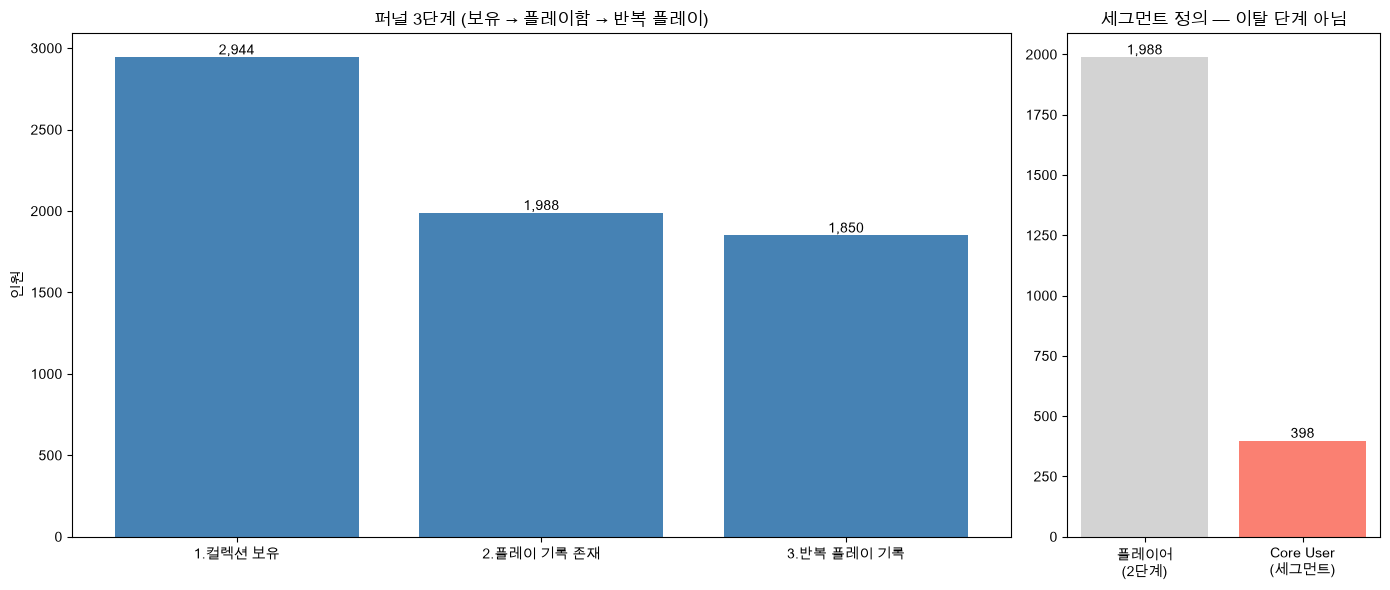

,stage_order,stage,n,conversion_from_prev,conversion_from_stage1
0,1,1.컬렉션 보유,2944,NaN,1.000000
1,2,2.플레이 기록 존재,1988,0.675272,0.675272
2,3,3.반복 플레이 기록,1850,0.930584,0.628397


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={"width_ratios": [3, 1]})

axes[0].bar(funnel_user_summary["stage"], funnel_user_summary["n"], color="steelblue")
axes[0].set_title("퍼널 3단계 (보유 → 플레이함 → 반복 플레이)")
axes[0].set_ylabel("인원")
for i, row in funnel_user_summary.iterrows():
    axes[0].text(i, row["n"], f"{row['n']:,}", ha="center", va="bottom")

n_players = int(funnel_core_segment["n_players"].iloc[0])
n_core = int(funnel_core_segment["n_core_users"].iloc[0])
axes[1].bar(["플레이어\n(2단계)", "Core User\n(세그먼트)"], [n_players, n_core], color=["lightgray", "salmon"])
axes[1].set_title("세그먼트 정의 — 이탈 단계 아님")
for i, v in enumerate([n_players, n_core]):
    axes[1].text(i, v, f"{v:,}", ha="center", va="bottom")

plt.tight_layout()
plt.show()

display(funnel_user_summary)

**결과**
- 3,000명 → 2,944명(98.1%) → 1,988명(67.5%) → 1,850명(93.1%)로 확인, Core User는 398명(플레이어 중 20.0%)
- 가장 큰 감소는 보유→플레이함 구간으로 확인(-32.5%p, 956명)
    - 이후 3~7절 전체가 이 구간(`has_play_record`)을 종속변수로 다룬다
- 2→3단계(반복 플레이) 감소는 6.9%p로 작아, 이 노트북에서는 깊게 다루지 않는다


<a id="sec-2"></a>
## 2. 데이터 준비, 파생 변수

- 이후 분석은 전부 `is_owner=True`(2,944명, 1단계 통과자) 부분집합에서, `has_play_record`(2단계 통과 여부)를 종속변수로 삼는다.

In [6]:
owners = funnel_user[funnel_user["is_owner"]].copy()
owners = owners.merge(user_info, on="user_id", how="left")

owners["collection_size"] = owners["n_owned"]
owners["log_collection_size"] = np.log1p(owners["collection_size"])
owners["days_since_login"] = (pd.Timestamp("2026-09-06") - pd.to_datetime(owners["lastlogin"], errors="coerce")).dt.days
owners["tenure_years"] = 2026 - owners["yearregistered"]
owners["rating_ratio"] = owners["n_rated"] / owners["n_owned"]

# 유저별 play_game_ratio: 소유 게임 중 실제로 플레이한 게임의 비율(컬렉션 규모를 통제한 지표, 5번에서 본격 사용)
play_ratio = funnel_item.groupby("user_id")["has_play_record"].mean().rename("play_game_ratio")
owners = owners.merge(play_ratio, on="user_id", how="left")

print(f"분석 대상: {len(owners):,}명")
owners[["collection_size", "days_since_login", "tenure_years", "rating_ratio", "play_game_ratio"]].describe().round(2)

분석 대상: 2,944명


,collection_size,days_since_login,tenure_years,rating_ratio,play_game_ratio
count,2944.00,2942.00,2944.00,2944.00,2944.00
mean,440.05,263.45,12.31,0.65,0.27
std,621.18,782.60,6.04,0.28,0.30
min,1.00,4.00,0.00,0.00,0.00
25%,96.00,5.00,8.00,0.43,0.00
50%,242.00,6.00,12.00,0.69,0.14
75%,532.25,58.75,17.00,0.90,0.51
max,7763.00,8203.00,27.00,1.00,1.00


**결과**
- 분석 대상 2,944명 전원에 `play_game_ratio`가 계산되는 것으로 확인(소유 게임이 1개 이상이므로 분모가 0인 경우 없음)
- `days_since_login`은 2명 결측으로 확인([EDA](01.EDA.ipynb) 1-1에서 이미 확인된 `lastlogin` 결측과 동일)
- `has_play_record=False`인 유저는 정의상 `play_game_ratio=0`인 것으로 확인
    - 이 값을 로지스틱 회귀의 독립변수로 쓰면 종속변수와 완전분리가 생긴다는 것을 시사
    - 그렇기 때문에 7번에서 `play_game_ratio`를 예측변수에서 제외한다


<a id="sec-3"></a>
## 3. User-level 드라이버 검증

- `has_play_record` True/False 두 그룹 사이에 4개 변수(보유 게임 수, 마지막 로그인 경과일, 가입 후 경과연수, 평가 참여율)의 분포가 다른지 Mann-Whitney U 검정으로 확인하고, 
- rank-biserial 효과크기로 크기를 잰다([EDA](01.EDA.ipynb) 2-3에서 확립한 "정규성을 가정하지 않는다" 원칙을 승계).

In [7]:
def mannwhitney_effect(df, col, group_col="has_play_record"):
    """두 그룹(True/False) 간 col 분포 차이를 Mann-Whitney U + rank-biserial r로 검정"""
    g1 = df.loc[df[group_col], col].dropna()
    g0 = df.loc[~df[group_col], col].dropna()
    u_stat, p_value = stats.mannwhitneyu(g1, g0, alternative="two-sided")
    rank_biserial = 1 - (2 * u_stat) / (len(g1) * len(g0))
    return pd.Series({
        "n_true": len(g1), "n_false": len(g0),
        "median_true": g1.median(), "median_false": g0.median(),
        "U": u_stat, "p_value": p_value, "rank_biserial_r": rank_biserial,
    })

,n_true,n_false,median_true,median_false,U,p_value,rank_biserial_r
0,1988.0,956.0,5.769881,4.774904,1355175.5,1.983524e-78,-0.426104


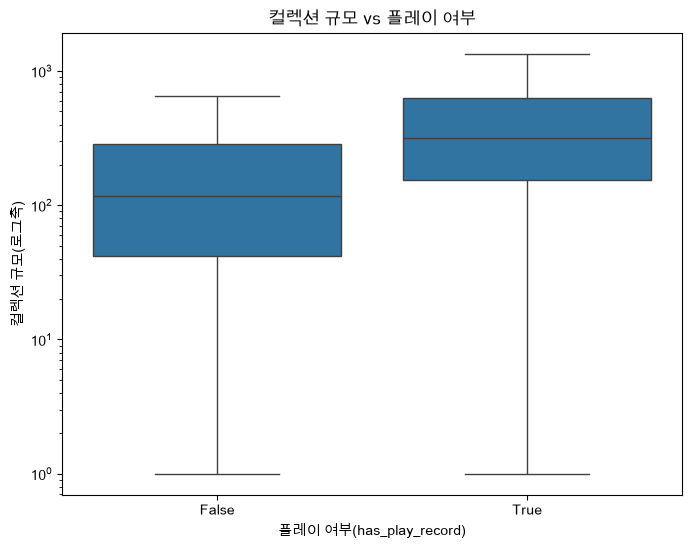

In [8]:
res_collection = mannwhitney_effect(owners, "log_collection_size")
display(res_collection.to_frame().T)

plt.figure(figsize=(8, 6))
sns.boxplot(data=owners, x="has_play_record", y="collection_size", showfliers=False)
plt.yscale("log")
plt.title("컬렉션 규모 vs 플레이 여부")
plt.xlabel("플레이 여부(has_play_record)")
plt.ylabel("컬렉션 규모(로그축)")
plt.show()

**결과**
- 보유 게임 수 중앙값은 플레이한 유저 244개, 안 한 유저 117개로 확인(로그 스케일 중앙값 5.77 vs 4.77)
    - Mann-Whitney p<0.001, rank-biserial r=-0.43(중간~큰 효과)로 확인, 4개 변수 중 가장 큰 효과크기
- [EDA](01.EDA.ipynb) 9-1에서 지적한 기계적 효과(보유 게임이 많을수록 1회 이상 기록 조건을 채우기 쉬움)가 섞여 있어 인과로 읽지 않는다
- 5번에서 `play_game_ratio`로 이 효과를 직접 통제한다


,n_true,n_false,median_true,median_false,U,p_value,rank_biserial_r
0,1988.0,954.0,5.0,14.0,678371.5,1.049908e-36,0.284627


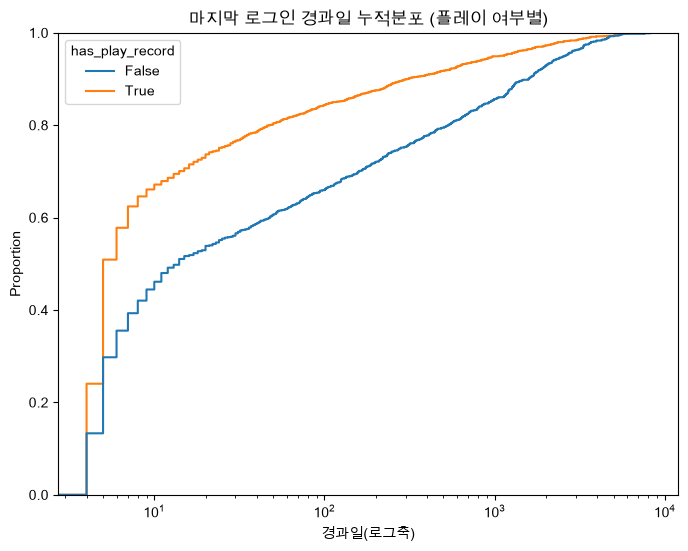

In [9]:
res_login = mannwhitney_effect(owners, "days_since_login")
display(res_login.to_frame().T)

plt.figure(figsize=(8, 6))
sns.ecdfplot(data=owners, x="days_since_login", hue="has_play_record")
plt.xscale("log")
plt.title("마지막 로그인 경과일 누적분포 (플레이 여부별)")
plt.xlabel("경과일(로그축)")
plt.show()

**결과**
- 마지막 로그인 경과일 중앙값은 플레이한 유저 5일, 안 한 유저 14일로 확인(p<0.001, r=+0.28, 작음~중간)
- [EDA](01.EDA.ipynb) 9-2와 동일한 가드레일 적용, 원인 변수가 아니라 현재 활동성 상태를 나타내는 보조 변수로만 읽는다
    - 방향이 반대일 수 있음(플레이하는 유저라서 로그인이 잦은 것일 수 있음)


,n_true,n_false,median_true,median_false,U,p_value,rank_biserial_r
0,1988.0,956.0,13.0,10.0,1191740.5,4.380151e-29,-0.254115


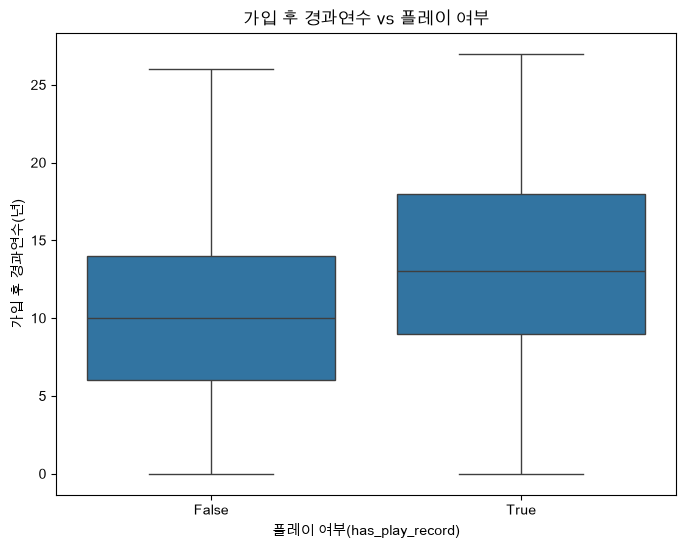

In [10]:
res_tenure = mannwhitney_effect(owners, "tenure_years")
display(res_tenure.to_frame().T)

plt.figure(figsize=(8, 6))
sns.boxplot(data=owners, x="has_play_record", y="tenure_years", showfliers=False)
plt.title("가입 후 경과연수 vs 플레이 여부")
plt.xlabel("플레이 여부(has_play_record)")
plt.ylabel("가입 후 경과연수(년)")
plt.show()

**결과**
- 가입 후 경과연수 중앙값은 플레이한 유저 13년, 안 한 유저 10년으로 확인(p<0.001, r=-0.25, 작음~중간)
    - 오래 가입한 유저일수록 플레이했다는 관계가 관측됨
- 다만 오래 가입했을수록 플레이할 시간 자체가 많았다는 누적 시간 교란이 섞여 있어, [EDA](01.EDA.ipynb) 9-2와 같은 이유로 인과로 단정하지 않는다


,n_true,n_false,median_true,median_false,U,p_value,rank_biserial_r
0,1988.0,956.0,0.630881,0.82466,670063.5,1.589163e-38,0.294866


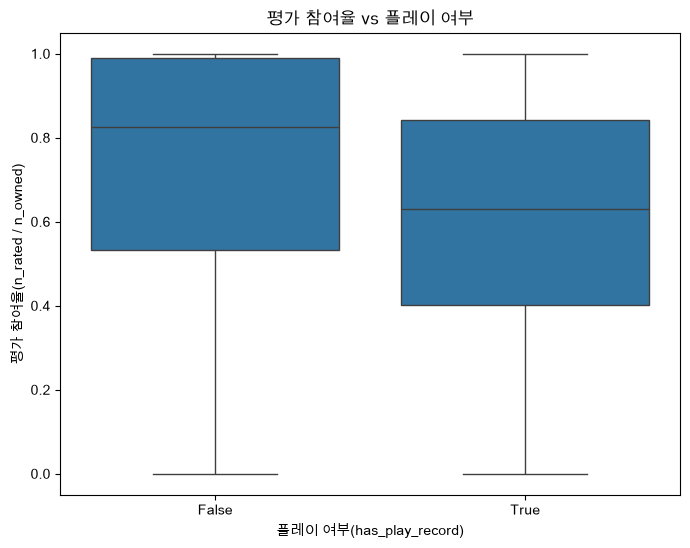

In [11]:
res_rating = mannwhitney_effect(owners, "rating_ratio")
display(res_rating.to_frame().T)

plt.figure(figsize=(8, 6))
sns.boxplot(data=owners, x="has_play_record", y="rating_ratio", showfliers=False)
plt.title("평가 참여율 vs 플레이 여부")
plt.xlabel("플레이 여부(has_play_record)")
plt.ylabel("평가 참여율(n_rated / n_owned)")
plt.show()

**결과**
- 평가 참여율 중앙값은 플레이한 유저 0.63, 안 한 유저 0.82로 확인
    - 평가 참여율이 오히려 더 높은 쪽이 플레이는 더 적은 것으로 확인(p<0.001, r=+0.29, 작음~중간)
- [EDA](01.EDA.ipynb) 8-3(평가 참여율 최상위 분위의 플레이 비율이 오히려 41.4%로 최저)과 방향이 일치
- 평가 참여는 퍼널의 순차 단계가 아니라 별개의 참여(참여도) 축이라는 [EDA](01.EDA.ipynb)의 결론을 여기서도 재확인


In [12]:
ranking = pd.DataFrame([
    ["컬렉션 규모(log)", res_collection["rank_biserial_r"], res_collection["p_value"]],
    ["평가 참여율", res_rating["rank_biserial_r"], res_rating["p_value"]],
    ["마지막 로그인 경과일", res_login["rank_biserial_r"], res_login["p_value"]],
    ["가입 후 경과연수", res_tenure["rank_biserial_r"], res_tenure["p_value"]],
], columns=["변수", "rank_biserial_r", "p_value"])
ranking["abs_r"] = ranking["rank_biserial_r"].abs()
ranking.sort_values("abs_r", ascending=False).drop(columns="abs_r")

,변수,rank_biserial_r,p_value
0,컬렉션 규모(log),-0.426104,1.983524e-78
1,평가 참여율,0.294866,1.589163e-38
2,마지막 로그인 경과일,0.284627,1.049908e-36
3,가입 후 경과연수,-0.254115,4.380151e-29


**결과**
- 효과크기 순위는 보유 게임 수(|r|=0.43) > 평가 참여율(0.29) ≈ 로그인 경과일(0.28) > 가입 후 경과연수(0.25)로 확인
- 넷 다 p<0.001이지만(n=2,944로 표본이 커서 항상 유의) 효과크기는 "중간" 이하로 확인
- 이는 어떤 변수 하나로 전환 여부를 강하게 설명하지 못한다는 것을 시사
- 그렇기 때문에 7번(로지스틱 회귀)에서 네 변수를 동시에 통제했을 때도 관계가 유지되는지 확인한다


<a id="sec-4"></a>
## 4. `play_game_ratio`로 보유 게임 수의 기계적 효과 통제

- 3번에서 보유 게임 수가 가장 큰 효과크기를 보였지만, [EDA](01.EDA.ipynb) 9-1은 이 관계에 **기계적 효과**가 섞여 있을 수 있다고 경고했다.
- 소유 게임이 많을수록 그중 하나라도 플레이할 확률이 자동으로 올라간다. 
- 이 절에서는 **플레이한 유저 안에서만** 보유 게임 수와 `play_game_ratio`(소유 게임 중 실제로 플레이한 게임의 비율)의 관계를 본다.
- 이진 통과 여부가 아니라 "얼마나 폭넓게 했는가"를 통제된 지표로 재본다.

size_q
1    0.403846
2    0.458333
3    0.416334
4    0.384600
5    0.306823
Name: play_game_ratio, dtype: float64

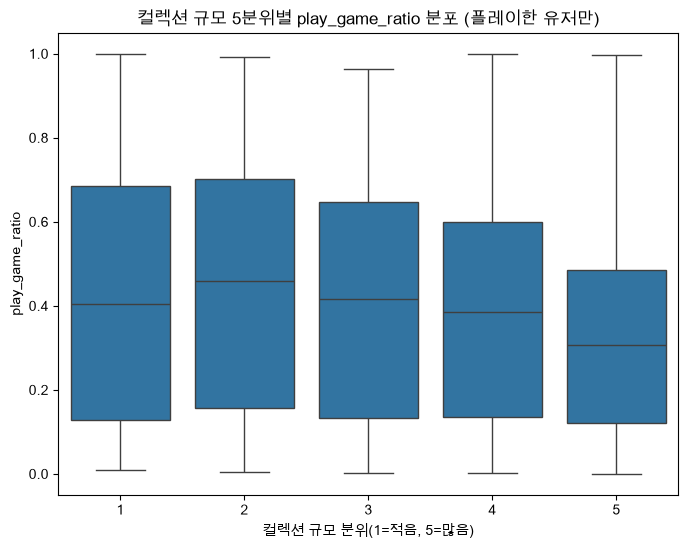

스피어만(log(컬렉션 규모), play_game_ratio), 플레이한 유저만: rho=-0.127, p=1.43e-08, n=1,988


In [13]:
players = owners[owners["has_play_record"]].copy()
players["size_q"] = pd.qcut(players["collection_size"], 5, labels=[1, 2, 3, 4, 5])

ratio_by_q = players.groupby("size_q", observed=True)["play_game_ratio"].median()
display(ratio_by_q)

plt.figure(figsize=(8, 6))
sns.boxplot(data=players, x="size_q", y="play_game_ratio", showfliers=False)
plt.title("컬렉션 규모 5분위별 play_game_ratio 분포 (플레이한 유저만)")
plt.xlabel("컬렉션 규모 분위(1=적음, 5=많음)")
plt.ylabel("play_game_ratio")
plt.show()

rho, p = stats.spearmanr(np.log(players["collection_size"]), players["play_game_ratio"])
print(f"스피어만(log(컬렉션 규모), play_game_ratio), 플레이한 유저만: rho={rho:.3f}, p={p:.2e}, n={len(players):,}")

**결과**
- `play_game_ratio` 중앙값이 분위 1(0.40)~2(0.46)에서 분위 5(0.31)로 오히려 낮아지는 것으로 확인
- 보유 게임이 클수록 "1회 이상 했다"는 낮은 문턱은 쉽게 넘지만, 소유한 게임 대비 실제로 플레이하는 비율은 오히려 낮은 것으로 확인
    - `has_play_record`라는 이진 지표는 대형 보유자의 약한 참여를 가릴 수 있다는 것을 시사
    - 다만 이 상관은 작은 편(0.13)이라 극적인 반전은 아님
- 이진 전환은 통제 없이 쓰면 대형 보유자의 전환을 과대평가할 수 있다는 정도로 읽는다
    - 임의의 "형식적 전환" 컷오프는 만들지 않는다


<a id="sec-5"></a>
## 5. Game-level 특성

- EDA에서 이미 "관계가 관측된다"까지 확인했던 복잡도/인기도를, 여기서는 기존 마트와 통계적으로 검증한다.

### 5-1. 게임 복잡도

In [14]:
display(funnel_item_by_complexity)

cx_df = funnel_item[funnel_item["complexity_bucket"].notna()][["complexity_bucket", "has_play_record"]].copy()
AdvanceEDA.check_chi2_test(cx_df, target="has_play_record")

,complexity_bucket,n_owned,n_with_play_record,play_record_rate,n_with_repeat_play_record,repeat_play_record_rate
0,1.가벼움(<2.0),382813,145010,0.378801,105604,0.275863
1,2.라이트(2.0-2.5),303657,87461,0.288026,59391,0.195586
2,3.미들(2.5-3.0),208841,54535,0.261132,36070,0.172715
3,4.미들헤비(3.0-3.5),177135,37536,0.211906,24978,0.141011
4,5.헤비(>=3.5),131291,32165,0.244990,22125,0.168519


,column,unique,chi2,p_value,cramers_v,expected_>=5_ratio,valid
0,complexity_bucket,5,21542.0368,0.0,0.1338,100.0,True


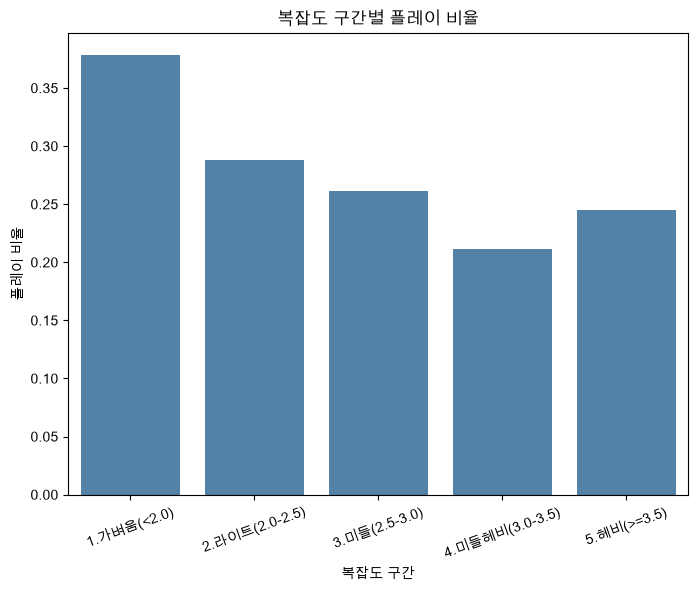

In [15]:
plt.figure(figsize=(8, 6))
sns.barplot(data=funnel_item_by_complexity, x="complexity_bucket", y="play_record_rate", color="steelblue")
plt.title("복잡도 구간별 플레이 비율")
plt.xlabel("복잡도 구간")
plt.ylabel("플레이 비율")
plt.xticks(rotation=20)
plt.show()

**결과**
- 카이제곱 p<0.001, Cramér's V=0.13(약함)로 확인
- 복잡도와 플레이 여부 사이에 통계적으로 유의하지만 크기는 작은 연관이 있는 것으로 확인
- 가벼운 게임(37.9%)에서 헤비 게임(24.5%)까지 대체로 감소하는 경향으로 확인, [EDA](01.EDA.ipynb) 9-3과 방향이 같음


### 5-2. 게임 인기도

In [16]:
item_pop = funnel_item.merge(item_popularity, on="objectid", how="left")
item_pop = item_pop[item_pop["owned"].notna()].copy()
item_pop["pop_q"] = pd.qcut(item_pop["owned"], 5, labels=["1", "2", "3", "4", "5"]).astype(str)

pop_rate = item_pop.groupby("pop_q")["has_play_record"].agg(["size", "mean"]).rename(columns={"mean": "play_record_rate"})
display(pop_rate)

pop_df = item_pop[["pop_q", "has_play_record"]].copy()
AdvanceEDA.check_chi2_test(pop_df, target="has_play_record")

,size,play_record_rate
pop_q,,
1,259291,0.173014
2,258983,0.204311
3,259059,0.259092
4,259097,0.319521
5,259083,0.448300


,column,unique,chi2,p_value,cramers_v,expected_>=5_ratio,valid
0,pop_q,5,60935.9304,0.0,0.2169,100.0,True


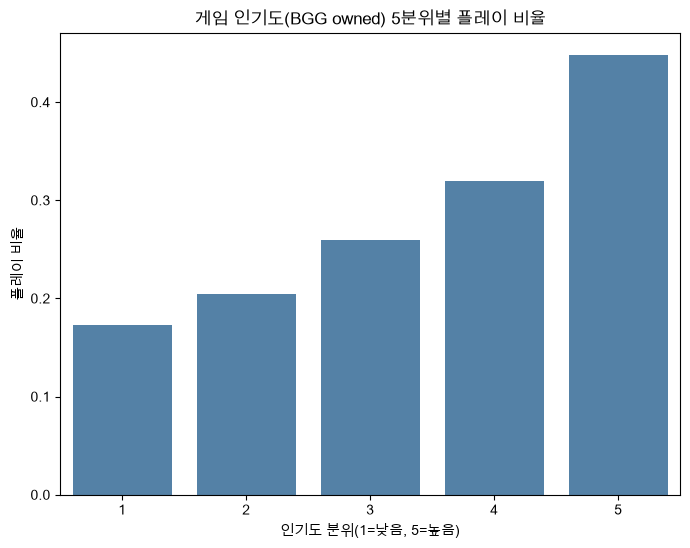

In [17]:
plt.figure(figsize=(8, 6))
sns.barplot(x=pop_rate.index, y=pop_rate["play_record_rate"], color="steelblue")
plt.title("게임 인기도(BGG owned) 5분위별 플레이 비율")
plt.xlabel("인기도 분위(1=낮음, 5=높음)")
plt.ylabel("플레이 비율")
plt.show()

**결과**
- 인기도 구간별 플레이 비율은 17.3% → 20.4% → 25.9% → 32.0% → 44.8%로 단조 증가하는 것으로 확인
- 카이제곱 p<0.001, Cramér's V=0.22로 확인
- 복잡도보다 크고, 이 노트북에서 검정한 아이템 축 변수 중 가장 강한 연관으로 확인


<a id="sec-6"></a>
## 6. 로지스틱 회귀, 여러 변수를 동시에 통제해도 관계가 유지되는가

- 3번은 변수 하나씩 봤다. 여기서는 네 변수를 동시에 넣어 서로를 통제한 뒤에도 각 변수가 `has_play_record`와 유의하게 연관되는지 확인
- **`play_game_ratio`는 예측변수에서 제외한다**
- 2번에서 확인했듯 `has_play_record=False`일 때 정의상 `play_game_ratio=0`이라 완전분리 문제가 생긴다. 
- 이 지표는 회귀가 아니라 4번의 서술적 분석에만 쓴다.

In [18]:
X_cols = ["log_collection_size", "days_since_login", "tenure_years", "rating_ratio"]
corr_matrix = owners[X_cols].corr(method="spearman")
corr_matrix.round(2)

,log_collection_size,days_since_login,tenure_years,rating_ratio
log_collection_size,1.00,-0.39,0.33,-0.41
days_since_login,-0.39,1.00,-0.07,0.13
tenure_years,0.33,-0.07,1.00,-0.15
rating_ratio,-0.41,0.13,-0.15,1.00


**결과**

- 예측변수 간 상관은 최대 |0.41|(보유 게임 수 ↔ 평가 참여율)로 확인
    - 회귀를 무의미하게 만들 만큼 심각한 다중공선성은 아니라는 것을 시사
- 변수가 4개뿐이라 전체 VIF 계산 없이 상관행렬로 충분히 점검된다


In [19]:
model_df = owners[["has_play_record"] + X_cols].dropna()
print(f"모델 n={len(model_df):,} (결측 제외 {len(owners) - len(model_df)}건)")

X = sm.add_constant(model_df[X_cols])
y = model_df["has_play_record"].astype(int)
logit_model = sm.Logit(y, X).fit(disp=0)
print(logit_model.summary())

모델 n=2,942 (결측 제외 2건)
                           Logit Regression Results                           
Dep. Variable:        has_play_record   No. Observations:                 2942
Model:                          Logit   Df Residuals:                     2937
Method:                           MLE   Df Model:                            4
Date:                Mon, 07 Sep 2026   Pseudo R-squ.:                  0.1239
Time:                        01:26:34   Log-Likelihood:                -1624.0
converged:                       True   LL-Null:                       -1853.6
Covariance Type:            nonrobust   LLR p-value:                 4.424e-98
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  -1.7949      0.256     -7.003      0.000      -2.297      -1.293
log_collection_size     0.4704      0.038     12.228      0.000       0.395       

In [20]:
conf = logit_model.conf_int()
conf.columns = ["2.5%", "97.5%"]
or_table = pd.DataFrame({
    "coef": logit_model.params,
    "OR": np.exp(logit_model.params),
    "OR_2.5%": np.exp(conf["2.5%"]),
    "OR_97.5%": np.exp(conf["97.5%"]),
    "p_value": logit_model.pvalues,
})
or_table.round(4)

,coef,OR,OR_2.5%,OR_97.5%,p_value
const,-1.7949,0.1662,0.1005,0.2746,0.0000
log_collection_size,0.4704,1.6006,1.4843,1.7259,0.0000
days_since_login,-0.0002,0.9998,0.9997,0.9999,0.0004
tenure_years,0.0493,1.0505,1.0346,1.0666,0.0000
rating_ratio,-0.6604,0.5166,0.3710,0.7195,0.0001


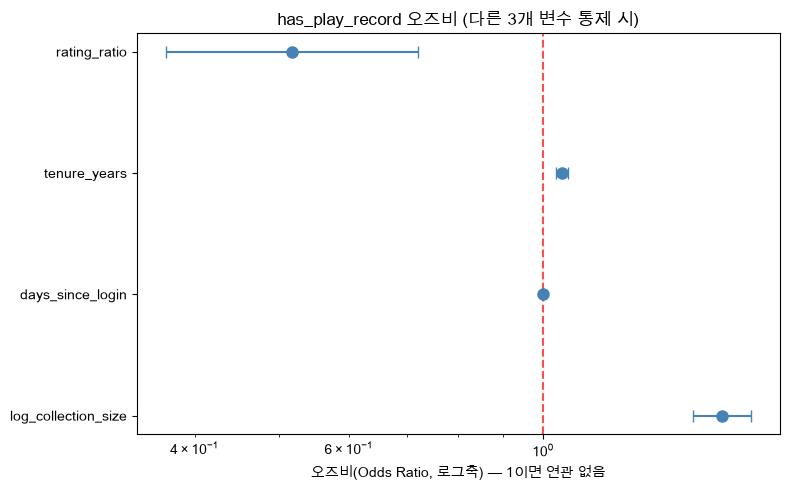

In [21]:
plot_table = or_table.drop("const")

plt.figure(figsize=(8, 5))
y_pos = np.arange(len(plot_table))
plt.errorbar(
    plot_table["OR"], y_pos,
    xerr=[plot_table["OR"] - plot_table["OR_2.5%"], plot_table["OR_97.5%"] - plot_table["OR"]],
    fmt="o", color="steelblue", capsize=4, markersize=8,
)
plt.axvline(1, color="red", linestyle="--", alpha=0.7)
plt.yticks(y_pos, plot_table.index)
plt.xscale("log")
plt.xlabel("오즈비(Odds Ratio, 로그축) — 1이면 연관 없음")
plt.title("has_play_record 오즈비 (다른 3개 변수 통제 시)")
plt.tight_layout()
plt.show()

**결과**
- 네 변수 전부 p<0.001로, 다른 변수를 통제한 뒤에도 통계적으로 유의한 연관이 유지되는 것으로 확인(McFadden 의사결정계수 0.12로 설명력 자체는 크지 않음)
- 보유 게임 수: 오즈비 1.60(95% CI 1.48~1.73)으로 확인
    - `log1p(보유 게임 수)`가 1 늘 때마다 플레이했을 오즈가 약 60% 높게 관측됨
- 평가 참여율: 오즈비 0.52(0.37~0.72)로 확인
    - 평가 참여율이 높을수록 오히려 플레이했을 오즈가 낮게 관측됨
- 가입 후 경과연수: 오즈비 1.05(1.03~1.07)로 확인
    - 연 단위로는 작지만 방향은 일관되게 양(+)
- 마지막 로그인 경과일: 오즈비 0.9998(1일당)로 확인
    - 통계적으로 유의하지만 실질적 크기는 매우 작음
- 이 모델은 설명적 모델이며, 여기서 나온 계수로 "무엇을 조작하면 전환이 는다"고 결론 내리지 않는다


<a id="sec-7"></a>
## 7. 결론

- 퍼널에서 가장 크게 빠지는 구간은 게임을 보유한 뒤 처음 플레이 기록을 남기기까지로 확인(-32.5%p, 956명)
    - 그다음 단계인 반복 플레이로의 감소는 6.9%p로 상대적으로 작음
    - 따라서 개입한다면 게임을 산 직후 첫 플레이를 유도하는 쪽이 우선순위

- 플레이 기록 여부와 가장 강하게 연관된 유저 특성은 보유 게임 수(효과 크기 0.43) > 평가 참여율(0.29) ≈ 마지막 로그인 이후 지난 날짜(0.28) > 가입 후 지난 햇수(0.25) 순으로 확인
    - 네 변수를 한 모델에 같이 넣어 서로의 영향을 걷어내고 봐도 전부 유의하게 남음
    - 다만 어느 하나가 결정적인 요인이라고 볼 수는 없음

- 게임 쪽 특성에서는 그 게임이 얼마나 유명한지(0.22)가 얼마나 복잡한지(0.13)보다 플레이 여부와 더 관련 있는 것으로 확인
    - [EDA](01.EDA.ipynb) 9-3·9-4에서 눈으로 본 경향을 통계 검정으로 재확인한 결과

보유 게임이 많은 유저는 "한 번이라도 해봤다"는 조건은 쉽게 통과하지만, 정작 가진 것 중 실제로 플레이한 비율은 오히려 낮았다(-0.13). 즉 "한 번이라도 했는지"만 보면 많이 가진 사람의 참여도를 실제보다 높게 평가하게 된다.

게다가 네 변수 모두 통계적으로는 유의했지만 각각의 효과 크기는 작거나 중간 수준이었고, 네 개를 다 합친 모델의 설명력도 약 12%에 그쳤다. 하나의 변수나 하나의 모델로 "누가 전환하는가"를 설명하려 해서는 안 된다는 뜻이다.

그래서 다음 분석에서는 세 가지를 가져간다.

- 보유 게임 수를 단독 기준으로 쓰지 않고, 가진 것 중 실제로 플레이한 비율과 함께 봐야 진짜 참여도가 드러난다
- 평가는 열심히 하는데 플레이 기록은 적은 집단이 실제로 존재하므로, 이들을 별도 유형으로 떼어놓고 본다
- 게임을 나눌 축으로는 복잡도보다 인기도(잘 알려진 게임인지 아닌지)를 먼저 고려한다
